Vitamin D Decay Analysis - Individual Replicates
Starting analysis at: 2026-02-26T14:24:14.337
Random seed reset for fresh optimization results

Current input data:
DECAY_START_POINTS: [53.952, 45.694, 55.112]
DECAY_END_POINTS: [38.103, 41.865, 42.774]
DECAY_DAYS: [26.0, 30.0, 81.0]

Individual Replicate Data:
--------------------------------------------------
Replicate 1:
  Initial concentration: 53.952
  Final concentration: 38.103
  Time period: 26.0 days
  Decay amount: 15.849

Replicate 2:
  Initial concentration: 45.694
  Final concentration: 41.865
  Time period: 30.0 days
  Decay amount: 3.829

Replicate 3:
  Initial concentration: 55.112
  Final concentration: 42.774
  Time period: 81.0 days
  Decay amount: 12.338

Processing Replicate 1...
    Initial: 53.952, Final: 38.103, Time: 26.0 days
    Running robust optimization...
      Using adaptive search range: [0.001338, 0.1338]
      Analytical estimate: 0.013377
        Trying algorithm 1/5: adaptive_de_rand_1_bin_radiuslimi

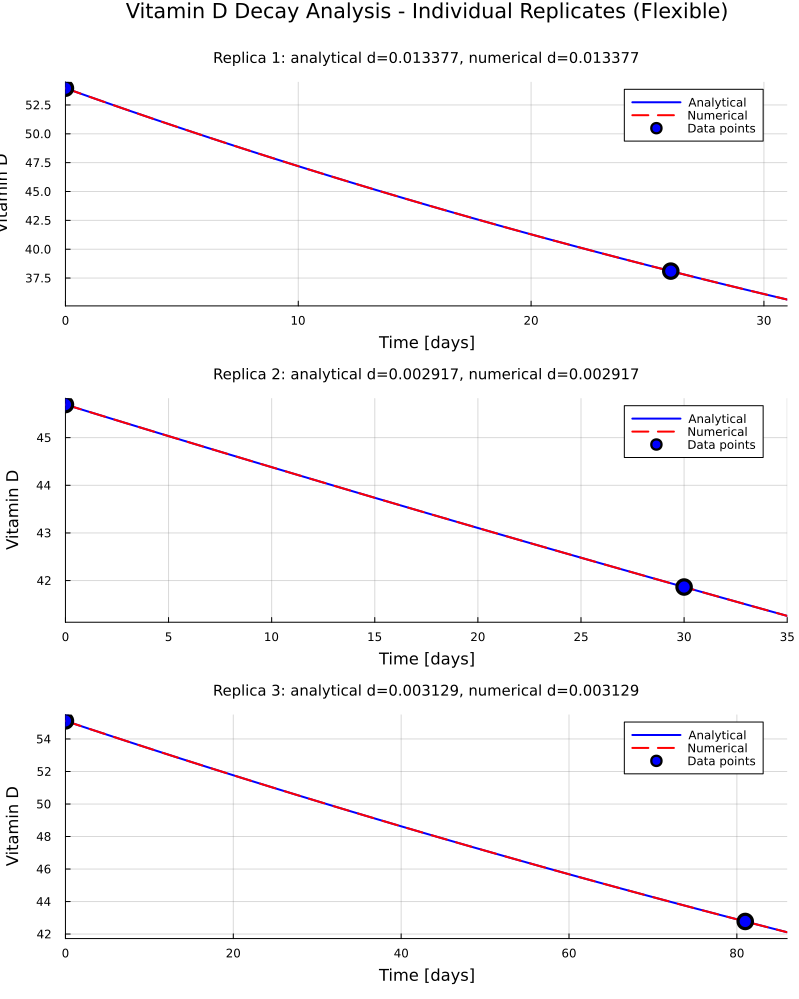

Plot saved as 'vitamin_d_decay_analysis_flexible_Feb.svg'

Summary Analysis:
Individual replicate analysis:
  Replicate 1:
    Initial: 53.952
    Final: 38.103
    Time: 26.0 days
    d (analytical) = 0.013377 per day
    d (numerical) = 0.013377 per day
    Half-life (analytical) = 51.8 days
    Half-life (numerical) = 51.8 days

  Replicate 2:
    Initial: 45.694
    Final: 41.865
    Time: 30.0 days
    d (analytical) = 0.002917 per day
    d (numerical) = 0.002917 per day
    Half-life (analytical) = 237.6 days
    Half-life (numerical) = 237.6 days

  Replicate 3:
    Initial: 55.112
    Final: 42.774
    Time: 81.0 days
    d (analytical) = 0.003129 per day
    d (numerical) = 0.003129 per day
    Half-life (analytical) = 221.5 days
    Half-life (numerical) = 221.5 days

Summary Statistics:
  Analytical d values:
    Mean: 0.006474 per day
    Std: 0.005979
    Range: 0.002917 - 0.013377
  Numerical d values:
    Mean: 0.006474 per day
    Std: 0.005979
    Range: 0.002917 - 0.

In [1]:
using Plots, BlackBoxOptim, Statistics, Dates, Random
using Printf

# ============================================================================
# MODIFY YOUR INPUT DATA HERE:
# ============================================================================

# Experimental data - Individual start and end points for each replicate
DECAY_START_POINTS = [53.952, 45.694, 55.112]  # Initial concentrations
DECAY_END_POINTS = [38.103, 41.865, 42.774]   # Final concentrations
DECAY_DAYS = [26.0, 30.0, 81.0]               # Time periods (days)

# ============================================================================

# Clear any cached results
if @isdefined(results)
    results = []
end
if @isdefined(plots_array)
    plots_array = []
end

# Reset random seed to ensure fresh optimization results
Random.seed!(Int(round(time() * 1000)) % 10000)

println("Vitamin D Decay Analysis - Individual Replicates")
println("="^60)
println("Starting analysis at: $(now())")
println("Random seed reset for fresh optimization results")
println()

println("Current input data:")
println("DECAY_START_POINTS: $DECAY_START_POINTS")
println("DECAY_END_POINTS: $DECAY_END_POINTS")
println("DECAY_DAYS: $DECAY_DAYS")
println()

println("Individual Replicate Data:")
println("-"^50)
for i in 1:3
    println("Replicate $i:")
    println("  Initial concentration: $(DECAY_START_POINTS[i])")
    println("  Final concentration: $(DECAY_END_POINTS[i])")
    println("  Time period: $(DECAY_DAYS[i]) days")
    println("  Decay amount: $(round(DECAY_START_POINTS[i] - DECAY_END_POINTS[i], digits=3))")
    println()
end

# Mathematical model
function VitD_function(V_0, d, t)
    """Exponential decay model: V(t) = V_0 * exp(-d*t)"""
    return V_0 * exp.(-d * t)
end

# Analytical solution for decay parameter
function d_analytical(V_exp, V_0, t)
    """Calculate decay parameter analytically: d = -ln(V_exp/V_0)/t"""
    return -log(V_exp / V_0) / t
end

# Cost function for numerical optimization with constraints
function cost_function(d, t_exp_single, y_exp_single, V_0)
    """Cost function to minimize: (predicted - observed)^2"""
    
    # Add penalty for unrealistic d values
    if d[1] <= 0 || d[1] > 10  # d should be positive and reasonable
        return 1e10
    end
    
    predicted = VitD_function(V_0, d[1], t_exp_single)  # d is a vector in BlackBoxOptim
    return (predicted - y_exp_single)^2
end

# Robust optimization function for decay analysis
function robust_optimization_decay(objective_func, V_0, V_exp, t_exp)
    """
    Perform robust optimization for decay parameter
    """
    
    # Estimate reasonable search range based on data
    analytical_d = d_analytical(V_exp, V_0, t_exp)
    
    # Adaptive search range around analytical solution
    d_min = max(0.001, analytical_d * 0.1)  # At least 10% of analytical
    d_max = min(10.0, analytical_d * 10.0)   # At most 10x analytical
    
    println("      Using adaptive search range: [$(round(d_min, digits=6)), $(round(d_max, digits=4))]")
    println("      Analytical estimate: $(round(analytical_d, digits=6))")
    
    # Multiple optimization algorithms
    algorithms = [
        :adaptive_de_rand_1_bin_radiuslimited,
        :de_rand_1_bin,
        :xnes,
        :separable_nes,
        :generating_set_search
    ]
    
    best_result = nothing
    best_fitness = Inf
    best_d = NaN
    all_results = []
    
    for (i, alg) in enumerate(algorithms)
        println("        Trying algorithm $i/$(length(algorithms)): $alg")
        
        # Multiple runs for each algorithm
        for run in 1:2  # Reduced to 2 runs to speed up
            try
                result = bboptimize(objective_func;
                                   Method = alg,
                                   SearchRange = [(d_min, d_max)],
                                   NumDimensions = 1,
                                   MaxSteps = 15000,
                                   MaxTime = 5.0,
                                   FitnessScheme = PenalizingFitnessScheme(1e10),
                                   TraceMode = :silent,
                                   RandomSeed = run * 54321)
                
                fitness = best_fitness(result)
                candidate = best_candidate(result)[1]
                
                push!(all_results, (algorithm=alg, run=run, fitness=fitness, d=candidate))
                
                if fitness < best_fitness
                    best_fitness = fitness
                    best_result = result
                    best_d = candidate
                end
            catch e
                println("          Warning: Algorithm $alg run $run failed: $e")
            end
        end
    end
    
    # Statistics on results
    if length(all_results) > 0
        all_d_values = [r.d for r in all_results if isfinite(r.fitness)]
        all_fitness_values = [r.fitness for r in all_results if isfinite(r.fitness)]
        
        if length(all_d_values) > 1
            println("        Results summary:")
            println("          Best d: $(round(best_d, digits=6))")
            println("          Mean d: $(round(mean(all_d_values), digits=6))")
            println("          Std d: $(round(std(all_d_values), digits=6))")
            println("          Best fitness: $(round(best_fitness, digits=8))")
            println("          Successful runs: $(length(all_d_values))/$(length(all_results))")
        end
    end
    
    return best_d, best_fitness, all_results
end

# Create plots array and results storage
plots_array = []
results = []

# Process each replica
for ii in 1:3
    println("Processing Replicate $ii...")
    
    # Get data for this replicate
    vitD_initial = DECAY_START_POINTS[ii]
    vitD_final = DECAY_END_POINTS[ii]
    time_period = DECAY_DAYS[ii]
    
    println("    Initial: $(vitD_initial), Final: $(vitD_final), Time: $(time_period) days")
    
    # Calculate analytical solution
    d_analytical_val = d_analytical(vitD_final, vitD_initial, time_period)
    
    # Robust numerical optimization
    println("    Running robust optimization...")
    objective(d) = cost_function(d, time_period, vitD_final, vitD_initial)
    
    d_numerical, optimization_cost, optimization_results = robust_optimization_decay(objective, vitD_initial, vitD_final, time_period)
    
    # Fallback if robust optimization fails
    if !isfinite(d_numerical) || d_numerical <= 0
        println("    Robust optimization failed, using analytical solution...")
        d_numerical = d_analytical_val
        optimization_cost = 0.0
        optimization_results = []
    end
    
    # Store results
    push!(results, (
        replicate = ii,
        d_analytical = d_analytical_val,
        d_numerical = d_numerical,
        vitD_initial = vitD_initial,
        vitD_final = vitD_final,
        time_period = time_period,
        optimization_cost = optimization_cost,
        optimization_stats = optimization_results
    ))
    
    # Create time vector for plotting
    t_simulation = range(0, time_period + 5, length=1000)
    
    # Calculate vitamin D levels using both solutions
    V_t_analytical = VitD_function(vitD_initial, d_analytical_val, t_simulation)
    V_t_numerical = VitD_function(vitD_initial, d_numerical, t_simulation)
    
    # Create individual plot
    p = plot(t_simulation, V_t_analytical, 
             linewidth=2, 
             color=:blue, 
             label="Analytical",
             xlabel="Time [days]",
             ylabel="Vitamin D",
             title="Replica $ii: analytical d=$(round(d_analytical_val, digits=6)), numerical d=$(round(d_numerical, digits=6))",
             titlefontsize=10,
             grid=true,
             gridwidth=1,
             gridcolor=:gray,
             gridalpha=0.3)
    
    # Add numerical solution
    plot!(p, t_simulation, V_t_numerical, 
          linewidth=2, 
          color=:red, 
          linestyle=:dash,
          label="Numerical")
    
    # Add experimental data points
    scatter!(p, [0, time_period], [vitD_initial, vitD_final], 
             markersize=8, 
             color=:blue, 
             markerstrokewidth=2,
             label="Data points")
    
    # Set x-axis limits
    xlims!(p, (0, maximum(t_simulation)))
    
    # Add to plots array
    push!(plots_array, p)
    
    # Print results
    println("    Results:")
    println("      Analytical d = $(round(d_analytical_val, digits=6))")
    println("      Numerical d = $(round(d_numerical, digits=6))")
    println("      Half-life (analytical): $(round(log(2)/d_analytical_val, digits=1)) days")
    println("      Half-life (numerical): $(round(log(2)/d_numerical, digits=1)) days")
    println("      Optimization cost: $(round(optimization_cost, digits=8))")
    println()
end

# Combine all plots
final_plot = plot(plots_array..., 
                 layout=(3,1), 
                 size=(800, 1000),
                 plot_title="Vitamin D Decay Analysis - Individual Replicates (Flexible)",
                 plot_titlefontsize=14)

# Display the plot
display(final_plot)

# Save the plot in SVG format
savefig(final_plot, "vitamin_d_decay_analysis_flexible_26Feb.svg")
println("Plot saved as 'vitamin_d_decay_analysis_flexible_Feb.svg'")

# Additional analysis
println("\nSummary Analysis:")
println("="^50)
println("Individual replicate analysis:")

# Collect all d values for summary statistics
analytical_d_values = []
numerical_d_values = []

for result in results
    push!(analytical_d_values, result.d_analytical)
    push!(numerical_d_values, result.d_numerical)
    
    println("  Replicate $(result.replicate):")
    println("    Initial: $(round(result.vitD_initial, digits=3))")
    println("    Final: $(round(result.vitD_final, digits=3))")
    println("    Time: $(result.time_period) days")
    println("    d (analytical) = $(round(result.d_analytical, digits=6)) per day")
    println("    d (numerical) = $(round(result.d_numerical, digits=6)) per day")
    println("    Half-life (analytical) = $(round(log(2)/result.d_analytical, digits=1)) days")
    println("    Half-life (numerical) = $(round(log(2)/result.d_numerical, digits=1)) days")
    
    # Optimization reliability
    if !isempty(result.optimization_stats)
        successful_runs = length([r for r in result.optimization_stats if isfinite(r.fitness)])
        total_runs = length(result.optimization_stats)
        println("    Optimization success rate: $successful_runs/$total_runs")
        
        if successful_runs > 1
            d_values = [r.d for r in result.optimization_stats if isfinite(r.fitness)]
            println("    Parameter variability (CV): $(round(std(d_values)/mean(d_values)*100, digits=2))%")
        end
    end
    println()
end

# Summary statistics
println("Summary Statistics:")
println("  Analytical d values:")
println("    Mean: $(round(mean(analytical_d_values), digits=6)) per day")
println("    Std: $(round(std(analytical_d_values), digits=6))")
println("    Range: $(round(minimum(analytical_d_values), digits=6)) - $(round(maximum(analytical_d_values), digits=6))")
println("  Numerical d values:")
println("    Mean: $(round(mean(numerical_d_values), digits=6)) per day")
println("    Std: $(round(std(numerical_d_values), digits=6))")
println("    Range: $(round(minimum(numerical_d_values), digits=6)) - $(round(maximum(numerical_d_values), digits=6))")
println("  Mean half-life (analytical): $(round(log(2)/mean(analytical_d_values), digits=1)) days")
println("  Mean half-life (numerical): $(round(log(2)/mean(numerical_d_values), digits=1)) days")

println("\nAnalysis completed at: $(now())")

Vitamin D Increase Analysis - Simple Flexible Version
Starting analysis at: 2026-02-26T14:25:32.419
Random seed reset for fresh optimization results
Using differential equation: d(VitD)/dt = k - d*VitD
Analytical solution: VitD(t) = (k/d) + (VitD0 - k/d) * exp(-d*t)

Current input data:
INCREASE_DATA: [[36.3, 42.2, 54.0], [38.1, 45.9, 45.7], [41.9, 48.2, 55.1]]
TIME_POINTS: [0.0, 24.0, 48.0]
DECAY_PARAMETERS_PER_DAY: [0.013377, 0.002917, 0.003129]
DECAY_PARAMETERS_PER_HOUR: [0.00055738, 0.00012154, 0.00013037]

Replicate 1:
  Data points: [36.3, 42.2, 54.0]
  Decay parameter d: 0.00055738 per hour
  (Converted from 0.013377 per day)
  Half-life: 1243.6 hours (51.82 days)

Replicate 2:
  Data points: [38.1, 45.9, 45.7]
  Decay parameter d: 0.00012154 per hour
  (Converted from 0.002917 per day)
  Half-life: 5703.0 hours (237.62 days)

Replicate 3:
  Data points: [41.9, 48.2, 55.1]
  Decay parameter d: 0.00013037 per hour
  (Converted from 0.003129 per day)
  Half-life: 5316.6 hours (221

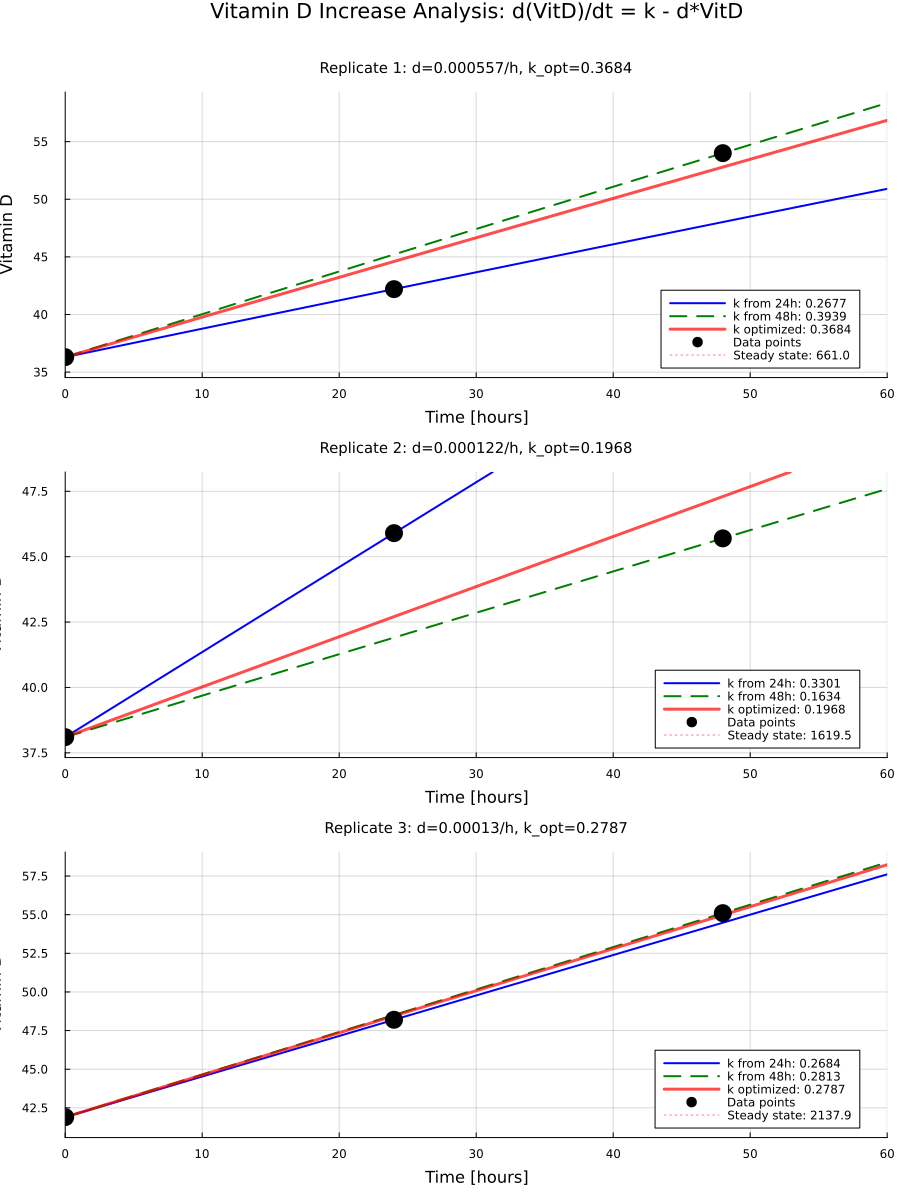

Plot saved as 'vitamin_d_increase_analysis_final.svg'

Summary Analysis:
Replicate | d (per hour) | k (24h) | k (48h) | k (opt) | Steady State | Half-life (days)
-------------------------------------------------------------------------------------
R1        | 0.000557     | 0.2677  | 0.3939  | 0.3684  | 661.0        | 51.82
R2        | 0.000122     | 0.3301  | 0.1634  | 0.1968  | 1619.5       | 237.62
R3        | 0.00013      | 0.2684  | 0.2813  | 0.2787  | 2137.9       | 221.52

Summary Statistics:
  Mean k (optimized): 0.2813 per hour
  Std k (optimized): 0.0858
  Mean steady state: 1472.8
  Range of steady states: 661.0 - 2137.9
  Mean half-life: 170.32 days
  Std half-life: 102.943 days
  Range of half-lives: 51.82 - 237.62 days

Daily rates:
  k values (per day): [8.84, 4.72, 6.69]
  Mean k (per day): 6.75

Model Validation:
  R1 predictions vs actual (half-life: 51.82 days):
    24h: 44.6 vs 42.2 (error: 2.4)
    48h: 52.79 vs 54.0 (error: 1.21)
  R2 predictions vs actual (half-l

In [2]:
using Plots, BlackBoxOptim, Statistics, Dates, Random
using Printf

# ============================================================================
# MODIFY YOUR INPUT DATA HERE:
# ============================================================================

# Experimental data for increase model
INCREASE_DATA = [
    [36.3,	42.2,	54],  # R1: 0h, 24h, 48h
    [38.1,	45.9,	45.7],  # R2: 0h, 24h, 48h  
    [41.9,	48.2,	55.1]   # R3: 0h, 24h, 48h
]

TIME_POINTS = [0.0, 24.0, 48.0]  # Time points in hours

# Decay parameters from previous analysis (per day, convert to per hour)
DECAY_PARAMETERS_PER_DAY = [0.013377, 0.002917, 0.003129]

# ============================================================================

DECAY_PARAMETERS_PER_HOUR = DECAY_PARAMETERS_PER_DAY ./ 24.0  # Convert to per hour

# Clear any cached results
if @isdefined(results)
    results = []
end
if @isdefined(plots_array)
    plots_array = []
end

# Reset random seed to ensure fresh optimization results
Random.seed!(Int(round(time() * 1000)) % 10000)

println("Vitamin D Increase Analysis - Simple Flexible Version")
println("="^65)
println("Starting analysis at: $(now())")
println("Random seed reset for fresh optimization results")
println("Using differential equation: d(VitD)/dt = k - d*VitD")
println("Analytical solution: VitD(t) = (k/d) + (VitD0 - k/d) * exp(-d*t)")
println()

println("Current input data:")
println("INCREASE_DATA: $INCREASE_DATA")
println("TIME_POINTS: $TIME_POINTS")
println("DECAY_PARAMETERS_PER_DAY: $DECAY_PARAMETERS_PER_DAY")
println("DECAY_PARAMETERS_PER_HOUR: $(round.(DECAY_PARAMETERS_PER_HOUR, digits=8))")
println()

# Display input data
for i in 1:3
    half_life_hours = log(2) / DECAY_PARAMETERS_PER_HOUR[i]
    half_life_days = half_life_hours / 24
    
    println("Replicate $i:")
    println("  Data points: $(INCREASE_DATA[i])")
    println("  Decay parameter d: $(round(DECAY_PARAMETERS_PER_HOUR[i], digits=8)) per hour")
    println("  (Converted from $(round(DECAY_PARAMETERS_PER_DAY[i], digits=6)) per day)")
    println("  Half-life: $(round(half_life_hours, digits=1)) hours ($(round(half_life_days, digits=2)) days)")
    println()
end

# Mathematical model for increase
function VitD_increase_function(VitD0, k, d, t)
    """
    Analytical solution to d(VitD)/dt = k - d*VitD
    VitD(t) = (k/d) + (VitD0 - k/d) * exp(-d*t)
    """
    steady_state = k / d
    return steady_state .+ (VitD0 .- steady_state) .* exp.(-d .* t)
end

# Analytical solution for k given two data points
function k_analytical_two_points(VitD0, VitD1, d, t1)
    """
    Calculate k analytically using two data points
    k = d * (VitD1 - VitD0 * exp(-d*t1)) / (1 - exp(-d*t1))
    """
    return d * (VitD1 - VitD0 * exp(-d * t1)) / (1 - exp(-d * t1))
end

# Cost function for numerical optimization (fits all data points)
function cost_function_increase(k, data_points, d, time_points)
    """Cost function to minimize: sum of squared errors for all data points"""
    VitD0 = data_points[1]  # Initial concentration
    total_error = 0.0
    
    for i in 2:length(data_points)  # Skip t=0 point
        predicted = VitD_increase_function(VitD0, k[1], d, time_points[i])
        error = (predicted - data_points[i])^2
        total_error += error
    end
    
    return total_error
end

# Create plots array and results storage
plots_array = []
results = []

# Process each replicate
for ii in 1:3
    println("Processing Replicate $ii...")
    
    data_points = INCREASE_DATA[ii]
    d_value = DECAY_PARAMETERS_PER_HOUR[ii]
    VitD0 = data_points[1]  # Initial concentration at t=0
    
    println("  Input data: $(data_points)")
    println("  d_value: $(d_value) per hour")
    
    # Method 1: Analytical solution using 24h and 48h data points
    k_24h = k_analytical_two_points(VitD0, data_points[2], d_value, TIME_POINTS[2])
    k_48h = k_analytical_two_points(VitD0, data_points[3], d_value, TIME_POINTS[3])
    
    # Method 2: Simple numerical optimization fitting all data points
    objective(k) = cost_function_increase(k, data_points, d_value, TIME_POINTS)
    
    result = bboptimize(objective; 
                       SearchRange = [(0.0, 10.0)],  # Search range for k
                       NumDimensions = 1,
                       MaxSteps = 10000,
                       TraceMode = :silent)
    
    k_optimized = best_candidate(result)[1]
    total_cost = best_fitness(result)
    
    # Store results
    push!(results, (
        replicate = ii,
        k_24h = k_24h,
        k_48h = k_48h,
        k_optimized = k_optimized,
        d_value = d_value,
        data = data_points,
        cost = total_cost
    ))
    
    # Create time vector for plotting
    t_simulation = range(0, 60, length=1000)  # Extended to 60 hours
    
    # Calculate vitamin D levels using different k values
    V_t_k24h = VitD_increase_function(VitD0, k_24h, d_value, t_simulation)
    V_t_k48h = VitD_increase_function(VitD0, k_48h, d_value, t_simulation)
    V_t_optimized = VitD_increase_function(VitD0, k_optimized, d_value, t_simulation)
    
    # Create individual plot
    p = plot(t_simulation, V_t_k24h, 
             linewidth=2, 
             color=:blue, 
             label="k from 24h: $(round(k_24h, digits=4))",
             xlabel="Time [hours]",
             ylabel="Vitamin D",
             title="Replicate $ii: d=$(round(d_value, digits=6))/h, k_opt=$(round(k_optimized, digits=4))",
             titlefontsize=10,
             grid=true,
             gridwidth=1,
             gridcolor=:gray,
             gridalpha=0.3,
             legend=:bottomright)
    
    # Add other solutions
    plot!(p, t_simulation, V_t_k48h, 
          linewidth=2, 
          color=:green, 
          linestyle=:dash,
          label="k from 48h: $(round(k_48h, digits=4))")
    
    plot!(p, t_simulation, V_t_optimized, 
          linewidth=3, 
          color=:red, 
          alpha=0.7,
          label="k optimized: $(round(k_optimized, digits=4))")
    
    # Add experimental data points
    scatter!(p, TIME_POINTS, data_points, 
             markersize=10, 
             color=:black, 
             markerstrokewidth=2,
             label="Data points")
    
    # Add steady state line
    steady_state = k_optimized / d_value
    hline!(p, [steady_state], 
           color=:red, 
           linestyle=:dot, 
           alpha=0.5,
           label="Steady state: $(round(steady_state, digits=1))")
    
    # Set axis limits - focus on data range, not steady state
    xlims!(p, (0, 60))
    data_range = maximum(data_points) - minimum(data_points)
    y_min = minimum(data_points) - 0.1 * data_range
    y_max = maximum(data_points) + 0.3 * data_range
    ylims!(p, (y_min, y_max))
    
    # Add to plots array
    push!(plots_array, p)
    
    # Print results
    half_life_hours = log(2) / d_value
    half_life_days = half_life_hours / 24
    
    println("  k from 24h data: $(round(k_24h, digits=6)) per hour")
    println("  k from 48h data: $(round(k_48h, digits=6)) per hour")
    println("  k optimized (all data): $(round(k_optimized, digits=6)) per hour")
    println("  Steady state: $(round(steady_state, digits=1))")
    println("  Half-life: $(round(half_life_hours, digits=1)) hours ($(round(half_life_days, digits=2)) days)")
    println("  Cost (RSS): $(round(total_cost, digits=4))")
    println()
end

# Combine all plots
final_plot = plot(plots_array..., 
                 layout=(3,1), 
                 size=(900, 1200),
                 plot_title="Vitamin D Increase Analysis: d(VitD)/dt = k - d*VitD",
                 plot_titlefontsize=14)

# Display the plot
display(final_plot)

# Save the plot in SVG format
savefig(final_plot, "vitamin_d_increase_analysis_finale.svg")
savefig(final_plot, "vitamin_d_increase_analysis_finale.png")
println("Plot saved as 'vitamin_d_increase_analysis_final.svg'")

# Summary analysis
println("\nSummary Analysis:")
println("="^50)

# Create summary table
println("Replicate | d (per hour) | k (24h) | k (48h) | k (opt) | Steady State | Half-life (days)")
println("-"^85)
for result in results
    half_life_days = log(2) / result.d_value / 24
    println("R$(result.replicate)        | $(rpad(round(result.d_value, digits=6), 12)) | $(rpad(round(result.k_24h, digits=4), 7)) | $(rpad(round(result.k_48h, digits=4), 7)) | $(rpad(round(result.k_optimized, digits=4), 7)) | $(rpad(round(result.k_optimized/result.d_value, digits=1), 12)) | $(round(half_life_days, digits=2))")
end
println()

# Summary statistics
k_optimized_values = [r.k_optimized for r in results]
steady_states = [r.k_optimized / r.d_value for r in results]
half_lives_days = [log(2) / r.d_value / 24 for r in results]

println("Summary Statistics:")
println("  Mean k (optimized): $(round(mean(k_optimized_values), digits=4)) per hour")
println("  Std k (optimized): $(round(std(k_optimized_values), digits=4))")
println("  Mean steady state: $(round(mean(steady_states), digits=1))")
println("  Range of steady states: $(round(minimum(steady_states), digits=1)) - $(round(maximum(steady_states), digits=1))")
println("  Mean half-life: $(round(mean(half_lives_days), digits=2)) days")
println("  Std half-life: $(round(std(half_lives_days), digits=3)) days")
println("  Range of half-lives: $(round(minimum(half_lives_days), digits=2)) - $(round(maximum(half_lives_days), digits=2)) days")

# Convert k values to per day for comparison
k_per_day = k_optimized_values .* 24
println("\nDaily rates:")
println("  k values (per day): $(round.(k_per_day, digits=2))")
println("  Mean k (per day): $(round(mean(k_per_day), digits=2))")

# Model validation
println("\nModel Validation:")
for (i, result) in enumerate(results)
    VitD0 = result.data[1]
    predicted_24h = VitD_increase_function(VitD0, result.k_optimized, result.d_value, 24.0)
    predicted_48h = VitD_increase_function(VitD0, result.k_optimized, result.d_value, 48.0)
    half_life_days = log(2) / result.d_value / 24
    
    println("  R$i predictions vs actual (half-life: $(round(half_life_days, digits=2)) days):")
    println("    24h: $(round(predicted_24h, digits=2)) vs $(result.data[2]) (error: $(round(abs(predicted_24h - result.data[2]), digits=2)))")
    println("    48h: $(round(predicted_48h, digits=2)) vs $(result.data[3]) (error: $(round(abs(predicted_48h - result.data[3]), digits=2)))")
end

#println("\nAnalysis completed at: $(now())")